Part 1

In [39]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor 
from sklearn.preprocessing import StandardScaler

In [40]:
McDonald = pd.read_excel("../data/PriceHistory.xlsx")
print(McDonald.head())

  Exchange Date   Close      %Chg     Volume
0    2026-09-30  252.53 -0.041777   34723607
1    2026-08-31  263.54 -0.026234   94987999
2    2026-07-31  270.64  0.001221   98550619
3    2026-06-30  270.31 -0.031841  101038413
4    2026-05-31  279.20 -0.049014   87304098


In [41]:
monthly_returns = McDonald['Close'].pct_change()
SMA_20 = McDonald['Close'].rolling(window=20).mean()
SMA_50 = McDonald['Close'].rolling(window=50).mean()

McDonald['SMA_20'] = SMA_20
McDonald['SMA_50'] = SMA_50
cleaned_data = McDonald.dropna(subset=['Close', 'SMA_20', 'SMA_50'])

1. I chose to work with McDonald's because it starts with the letter M and my name is Maria. 

2. I am analyzing 5 years of information and it's monthly so approximately 60 months. 

3. I created the daily returns variable, the SMA 20 variable, and the SMA 50 variable.

4. The daily return can help analyze the changes in the closing prices along the years, the simple moving averages can help with the general trend of the stock prices.

Part 2 & 3

In [42]:
target_variable = cleaned_data['Close'].shift(-1)
features = cleaned_data[['SMA_20', 'SMA_50', 'Close']]

valid_rows = target_variable.notna()
target_variable = target_variable[valid_rows]
features = features.loc[valid_rows]

mean = features.mean()
std = features.std()
features_normalized = (features - mean) / std

target_mean = target_variable.mean()
target_std = target_variable.std()
target_normalized = (target_variable - target_mean) / target_std


The objective of this model is to learn how the company's current monthly price and long-term trends like the sma20 and 50 relate to how the price will close the next month. And normalization puts all the input numbers in the same scale so the values that are bigger don't make the smaller values disappear. It helps the model learn faster and avoid getting stuck during the training with the data.

Part 4

In [44]:
split_index = int(len(features) * 0.8)
X_train = features_normalized.iloc[:split_index]
y_train = target_normalized.iloc[:split_index]
X_test = features_normalized.iloc[split_index:]
y_test = target_normalized.iloc[split_index:]

If we shuffle the data then the future stock prices can end up in the training set while the past ones in the test. Having the order helps the model make sure the evaluation is strictly on how the actual performance is in real life.

Part 5

In [48]:
model = MLPRegressor(hidden_layer_sizes=(20,), max_iter=1000, random_state=1)
model.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(20,), max_iter=1000, random_state=1)

We have three input variables which are the SMA20, SMA50, and Close. The hidden layers would be 1, the numebr of neurons are 20. The output would be the numerical outcup representing the closing price for the next month in usd. And the Maximum iterations are 1,000.

Part 6

In [54]:
prediction_normalized = model.predict(X_test)
prediction = prediction_normalized * target_std + target_mean
y_test_usd = target_variable.iloc[split_index:]

comparison_df = pd.DataFrame({
    'Actual ($)': y_test_usd,
    'Predicted ($)': prediction
}, index=y_test_usd.index)

print("Predictions (USD):")
print(prediction)
print("\nComparison DataFrame:")
print(comparison_df)

Predictions (USD):
[276.23900732 279.32494289 289.38102754]

Comparison DataFrame:
    Actual ($)  Predicted ($)
57      244.60     276.239007
58      245.55     279.324943
59      241.11     289.381028


Here I made the predicted variables and compared it to the actual prices. Here he can see that the actual price is lower than the predected.

Part 7

In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_usd, prediction))
mae = mean_absolute_error(y_test_usd, prediction)

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")

Root Mean Squared Error (RMSE): 38.608572671057416
Mean Absolute Error (MAE): 37.894992582740706


The MAE in the finance world is the average of how many dollars the model predicted were off. And the RMSE is also the measure of the errors but it actually get's higher number if the model has higher bad guesses, so it tells us that the model can make wrong predictions during volatile months.

Part 8

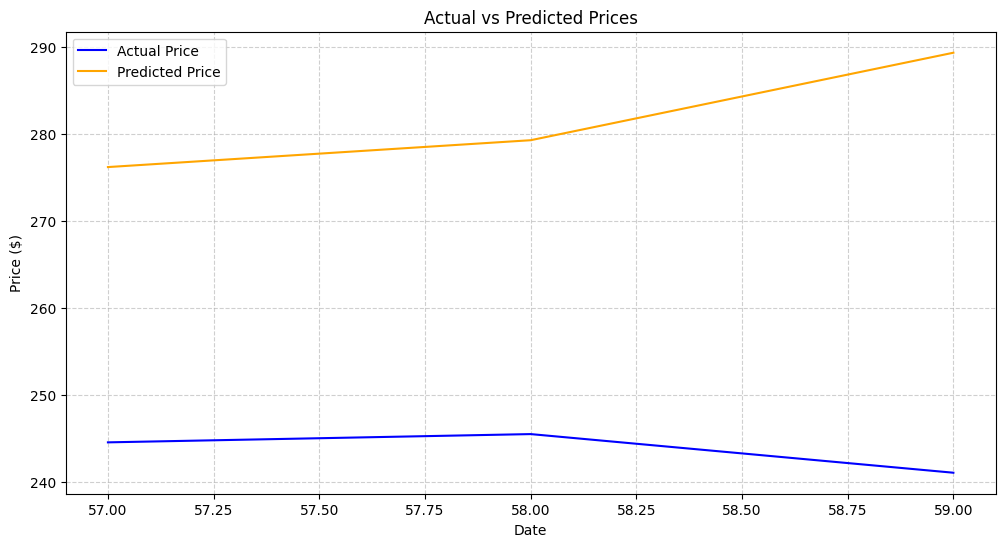

In [56]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.plot(y_test_usd.index, y_test_usd, label='Actual Price', color='blue')
plt.plot(y_test_usd.index, prediction, label='Predicted Price', color='orange')

plt.title('Actual vs Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

No, the prediction does not follow the real price movement. I believe something may be wrong with the code, if not then the model's prediction was not really close as expected.

Part 9

In [57]:
benchmark_prediction = features['Close'].iloc[split_index - 1]
actual_usd = target_variable.iloc[split_index:].values

benchmark_rmse = np.sqrt(mean_squared_error(actual_usd, [benchmark_prediction] * len(actual_usd)))
print(f"Benchmark RMSE: {benchmark_rmse}")

normal_rmse = np.sqrt(mean_squared_error(actual_usd, prediction))
print(f"Model RMSE: {normal_rmse}")

Benchmark RMSE: 15.812316929111498
Model RMSE: 38.608572671057416


No, the model's RMSE was worse than the benchmark. The simple one was 15.81 while the model one was 38.60. Which means the model's predictions were more than twice off from the real prices.

Part 10

Reflection

1. No, I believe that the neural network produced unaccurate predictions, since as we can see it was off by a lot. 

2. No it performed worse, significantly. The simple one had an RMSE of 15 while the model was 38. It was off by twice the actual one. 

3. I believe that the most useful one was the closing price since it is the one that can act as a predictor for the future prices. 

4. The limitations were maybe that I use monthly data, and the models use thousands of data. The models don't use other drivers of the market like indicators, market sentiment, etc, which can make the model a bit unaccurate. 

5. I wouldn't use the model alone to make investment decision because: I had trouble making the code, it was difficult to actually know if it was working correctly. Also because as we can see, it was highly unaccurate. 

6. This activity relates to the Weak Form of the EMH because the weak form states that the prices already reflect the past price information, and past patterns cannot be fully used to predict future prices, and the model uses past data and the moving averages that I added which is why it was off by a lot.